In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cmocean 
import cftime
import gsw
import wocemaps
import cartopy
import cartopy.crs as ccrs

### load time mean global Temerpature (T) and Salinity (S) (function of latitude, longitude, and depth)

In [2]:
woa18_data = xr.open_zarr('../data/woa18_full_decadal_ave_fields/')

# ocean depth
etopo5_data = xr.open_dataset('http://iridl.ldeo.columbia.edu/SOURCES/.NOAA/.NGDC/.ETOPO5/dods')
etopo5_data = etopo5_data.rename({'X': 'lon', 'Y': 'lat'})
etopo5_data['elev_ocean'] = etopo5_data.elev.where(etopo5_data.elev<0).load()
etopo5_data

<xarray.Dataset>
Dimensions:     (lon: 4320, lat: 2160)
Coordinates:
  * lon         (lon) float32 0.0 0.08333 0.1667 0.25 ... 359.8 359.8 359.9
  * lat         (lat) float32 90.0 89.92 89.83 89.75 ... -89.75 -89.83 -89.92
Data variables:
    elev        (lat, lon) int16 -4290 -4290 -4290 -4290 ... 2774 2774 2774 2774
    elev_ocean  (lat, lon) float32 -4.29e+03 -4.29e+03 -4.29e+03 ... nan nan nan
Attributes:
    dataset_documentation.html:  http://iridl.ldeo.columbia.edu/SOURCES/.NOAA...
    Conventions:                 IRIDL
    description:                 ETOPO5 5x5 minute land surface elevations an...

In [3]:
# key fields we'll be working with
temp = woa18_data.temp
salt = woa18_data.salinity
depth = woa18_data.depth
elev = etopo5_data.elev
elev_ocean = etopo5_data.elev_ocean

## In this exercise, we are going to use global fields of T and S to:

- compute potential density
- estimate horizontal density gradients
- leverage the thermal wind relation to estimate geostrophic velocities associated with density gradients

We'll walk through a procedure step by step and generate some figures to get a sense of the distributions of temperature, salinity, and density throughout the ocean

### todo: Using the gibbs seawater package (gsw), compute at all latitudes, longitudes, and depths potential density referenced to the surface (sigma0). 

This will first require calculations of absolute salinity and conservative temperature. Remember sigma references some density - 1000 km/m^3.

In [4]:
#salt

#### Part 1: absolute salinity
WOA18 salinity is practical salinity. So we can use the gsw_SA_from_SP function! However, this needs pressure as well. So we need to use gsw_p_from_z, which needs height instead of z. If using MATLAB, we could use the gsw_z_from_depth function to calculate height in a funny way, similar to the [SDS sheet for water](https://www.sigmaaldrich.com/US/en/sds/sigma/w4502?srsltid=AfmBOoqOij7UADYGeNls588jwNOmhrR7EcKzW-leQVohgsQdfkeQI2SG) (in which the wise chemists of Sigma-Aldrich suggest that if water is swallowed, "make victim drink water (two glasses at most). Consult doctor if feeling unwell."). However, since this is Python, we have to multiply it by -1 and be content, unfortunately.

In [5]:
pressure=gsw.p_from_z(-depth,woa18_data.lat)
#pressure.plot() #this makes sense

In [6]:
abs_salt=gsw.SA_from_SP(salt,pressure,salt.lon,salt.lat)
#abs_salt.values #ok yay

#### Part 2: conservative temperature
There's another gsw function we can use, gsw_CT_from_t! This takes in abs_salt and pressure.

In [7]:
#temp

In [8]:
cons_temp=gsw.CT_from_t(abs_salt,temp,pressure)
#cons_temp.values #ok!

#### Part 3: potential density
We can use gsw_rho, and call for potential density using 1000 km/m^3. In the documentation, the reference density was in dbar, so I'll be using 0.98 dbar.

In [9]:
pot_rho=gsw.rho(abs_salt,cons_temp,0.98)
pot_rho=pot_rho.rename('pot_rho')
pot_rho

<xarray.DataArray 'pot_rho' (depth: 102, lat: 180, lon: 360)>
dask.array<rho, shape=(102, 180, 360), dtype=float64, chunksize=(26, 45, 180), chunktype=numpy.ndarray>
Coordinates:
  * depth    (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
  * lat      (lat) float32 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
Attributes:
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    coordinates:    time lat lon depth
    grid_mapping:   crs
    long_name:      Objectively analyzed mean fields for sea_water_salinity a...
    standard_name:  sea_water_salinity
    units:          1e-3

### todo: Using cartopy produce a global map of T, S and potential density at the surface and at 1000m depth. 

Text(0.5, 0.98, 'Temperature, Salinity, and Potential Density')

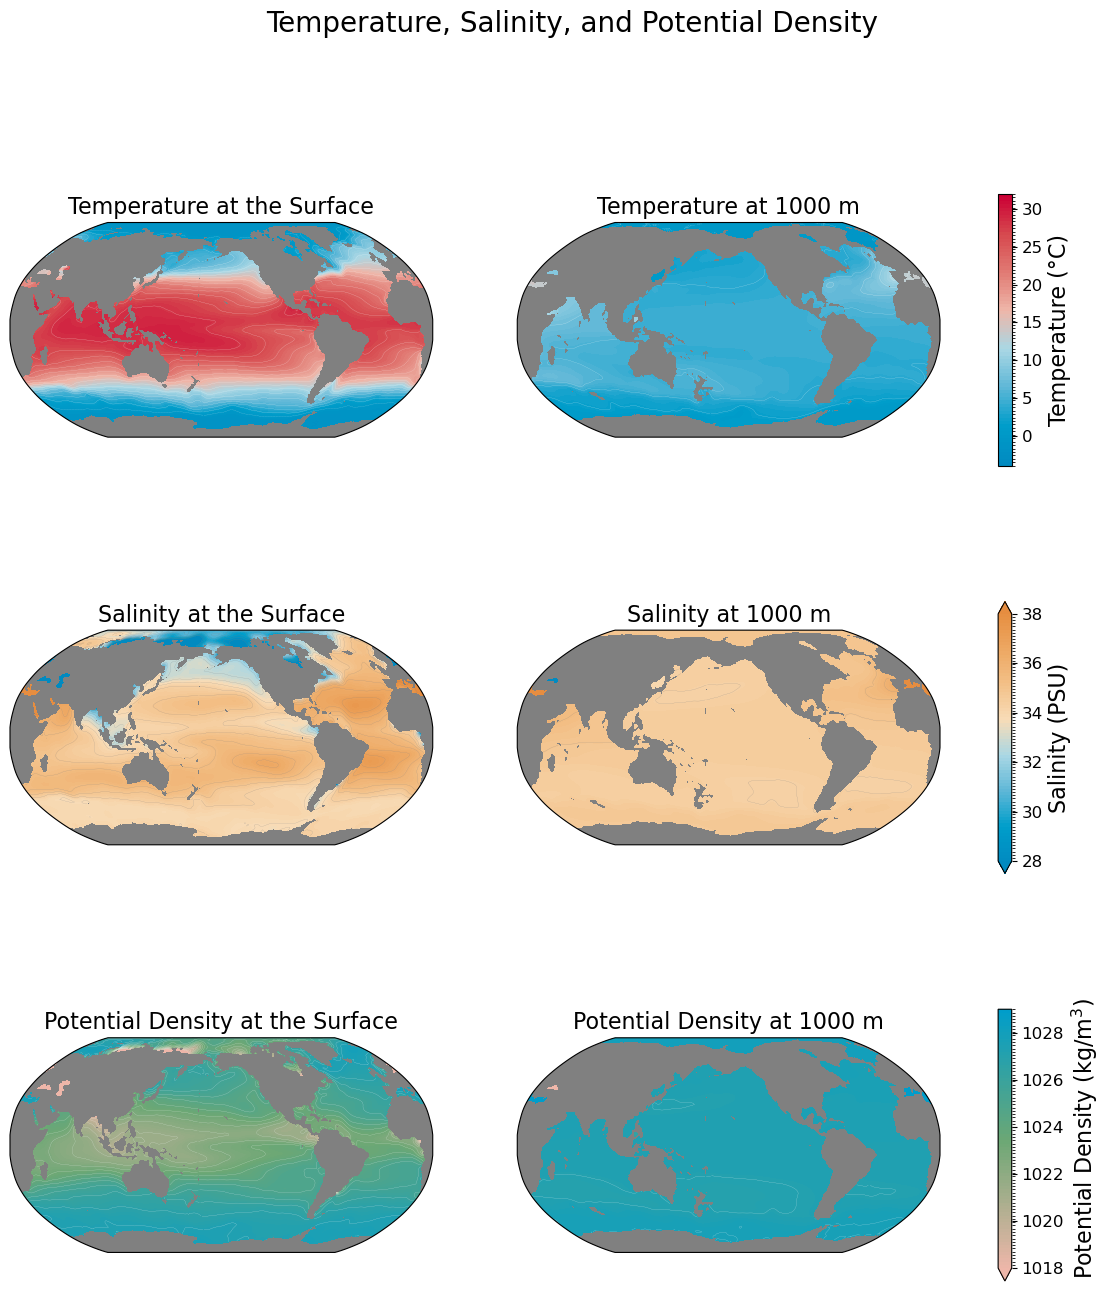

In [10]:
#setup

subplot_kws=dict(projection=ccrs.Robinson(central_longitude=-160),facecolor='grey')

fig,((ax1,ax2),(ax3,ax4),(ax5,ax6))=plt.subplots(ncols=2,nrows=3,figsize=(15,15),subplot_kw=subplot_kws)

axlist1=[ax1,ax2]
axlist2=[ax3,ax4]
axlist3=[ax5,ax6]

#1

t=temp.sel(depth=0).plot.contourf(ax=ax1,vmin=-4,vmax=32,levels=80,transform=ccrs.PlateCarree(),cmap=wocemaps.potentialtemp,add_colorbar=False)
temp.sel(depth=0).plot.contour(ax=ax1,vmin=-4,vmax=32,levels=20,transform=ccrs.PlateCarree(),colors='white',linewidths=0.1)
ax1.set_title('Temperature at the Surface',fontsize=16)

#2

temp.sel(depth=1000).plot.contourf(ax=ax2,vmin=-4,vmax=32,levels=80,transform=ccrs.PlateCarree(),cmap=wocemaps.potentialtemp,add_colorbar=False)
temp.sel(depth=1000).plot.contour(ax=ax2,vmin=-4,vmax=32,levels=20,transform=ccrs.PlateCarree(),colors='white',linewidths=0.1)
ax2.set_title('Temperature at 1000 m',fontsize=16)

#3

s=salt.sel(depth=0).plot.contourf(ax=ax3,vmin=28,vmax=38,levels=80,transform=ccrs.PlateCarree(),cmap=wocemaps.salinity,add_colorbar=False)
salt.sel(depth=0).plot.contour(ax=ax3,vmin=28,vmax=38,levels=20,transform=ccrs.PlateCarree(),colors='gray',linewidths=0.1)
ax3.set_title('Salinity at the Surface',fontsize=16)

#4

salt.sel(depth=1000).plot.contourf(ax=ax4,vmin=28,vmax=38,levels=80,transform=ccrs.PlateCarree(),cmap=wocemaps.salinity,add_colorbar=False)
salt.sel(depth=1000).plot.contour(ax=ax4,vmin=28,vmax=38,levels=20,transform=ccrs.PlateCarree(),colors='gray',linewidths=0.1)
ax4.set_title('Salinity at 1000 m',fontsize=16)

#5

r=pot_rho.sel(depth=0).plot.contourf(ax=ax5,vmin=1018,vmax=1029,levels=80,transform=ccrs.PlateCarree(),cmap=wocemaps.pdensity,add_colorbar=False)
pot_rho.sel(depth=0).plot.contour(ax=ax5,vmin=1018,vmax=1029,levels=20,transform=ccrs.PlateCarree(),colors='white',linewidths=0.1)
ax5.set_title('Potential Density at the Surface',fontsize=16)

#6

pot_rho.sel(depth=1000).plot.contourf(ax=ax6,vmin=1018,vmax=1029,levels=80,transform=ccrs.PlateCarree(),cmap=wocemaps.pdensity,add_colorbar=False)
pot_rho.sel(depth=1000).plot.contour(ax=ax6,vmin=1018,vmax=1029,levels=20,transform=ccrs.PlateCarree(),colors='white',linewidths=0.1)
ax6.set_title('Potential Density at 1000 m',fontsize=16)

#colorbar

cb1=fig.colorbar(t,ticks=[0,5,10,15,20,25,30],shrink=0.8,ax=axlist1)
cb1.set_label(label='Temperature (°C)', size=16)
cb1.ax.tick_params(labelsize=12)

cb2=fig.colorbar(s,ticks=[28,30,32,34,36,38],shrink=0.8,ax=axlist2)
cb2.set_label(label='Salinity (PSU)', size=16)
cb2.ax.tick_params(labelsize=12)

cb3=fig.colorbar(r,ticks=[1018,1020,1022,1024,1026,1028],shrink=0.8,ax=axlist3)
cb3.set_label(label='Potential Density (kg/m$^3$)', size=16)
cb3.ax.tick_params(labelsize=12)

#plot
 
fig.suptitle('Temperature, Salinity, and Potential Density',fontsize=20)

### todo: Write a few sentences about the patterns you observe (i.e. why is it warmer or saltier in certain regions?)

For all three plots, the variability really evens out at 1000 m--the deep ocean is more uniform than the surface ocean. There is still some regional variability, though it's much less drastic in the deep ocean than the surface.          
The surface temperature is higher with increasing proximity to the equator, but the deep ocean is much colder. The poles are coldest, but the region of the Atlantic adjacent to the Mediterranean is relatively warm. Additionally, this region at both the surface and 1000 m is incredibly salty. I think that this is due to the properties of the water mass that is spilling over from the Mediterranean.
![](mediterranean_water_masses.jpg)


Levantine Intermediate Water is about 13.0°C, which is close to the temperature seen in the plot. It is also very salty, about 38.4 PSU, which is close to the salinity seen in the plot. With regards to salinity elsewhere, generally, the freshest waters are towards the Arctic, and are also fresh of  of some coasts. The Southern Ocean is saltier than I thought! The poles have fresh water because of brine rejection, and my guess is that the Arctic has fresher waters because of precipitation or river input. My guess is that some regions along some coasts are fresh because of water systems.

### todo: Plot a cross section of potential density at 30W longitude (across all latitudes)
Lon values in this dataset are from -179.5 to +179.5°E, so 30°W is -150°E. I'll take an average of -150.5 and -149.5°E, since that seems like the simplest method to get 30°W, and this conversion isn't the focus of the notebook.

In [11]:
pot_rho_1495=pot_rho.sel(lon=-149.5)
pot_rho_1505=pot_rho.sel(lon=-150.5)
pot_rho_cross=(pot_rho_1495+pot_rho_1505)/2
pot_rho_cross

<xarray.DataArray 'pot_rho' (depth: 102, lat: 180)>
dask.array<truediv, shape=(102, 180), dtype=float64, chunksize=(26, 45), chunktype=numpy.ndarray>
Coordinates:
  * depth    (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
  * lat      (lat) float32 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5

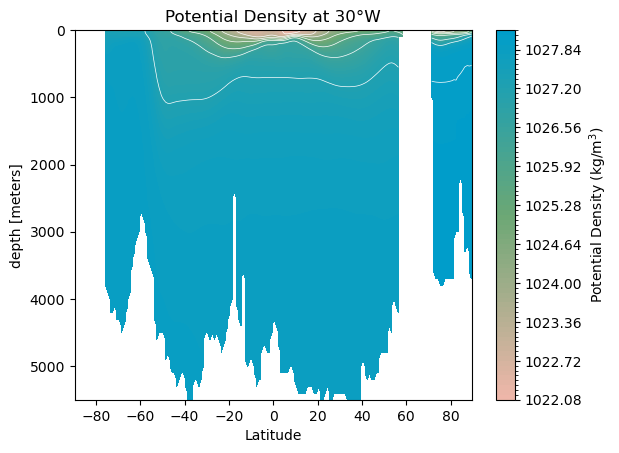

In [12]:
fig,ax=plt.subplots()
x=pot_rho_cross.plot.contourf(ax=ax,levels=80,yincrease=False,cmap=wocemaps.pdensity,add_colorbar=False)
pot_rho_cross.plot.contour(ax=ax,levels=10,yincrease=False,colors='white',linewidths=0.5)
ax.set_xlabel('Latitude')
ax.set_ylabel=('Depth (m)')
ax.set_title('Potential Density at 30°W')
cb=fig.colorbar(x,ax=ax)
cb.set_label(label='Potential Density (kg/m$^3$)')

### todo: Along this cross-section, estimate and plot horizontal gradients of potential density ($\frac{\partial \sigma_0}{\partial y}$) 

(consider using the centered difference method and ignoring the latitudes for which a centered difference would be incomplete)

In [13]:
longitude=-150
pot_rho_cross['longitude']=longitude
pot_rho_cross

<xarray.DataArray 'pot_rho' (depth: 102, lat: 180)>
dask.array<truediv, shape=(102, 180), dtype=float64, chunksize=(26, 45), chunktype=numpy.ndarray>
Coordinates:
  * depth      (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
  * lat        (lat) float32 -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
    longitude  int64 -150

We have latitude given in degrees, but we need to convert it to distance in order to get dy. I'll pull in the function I created for the geostrophy notebook. This is the distance between latitude values, not longitude, so it'll use the deltay function. I'll alter the deltay function so as to only require lat.

In [14]:
def deltay(lat,lon):

    lat_ar=np.asarray(lat) 
    lon_ar=np.atleast_1d(np.asarray(lon))
    
    deltay=np.empty((len(lat_ar)-2,len(lon_ar)))
    for j in range(1, len(lat_ar)-1):
        lat2=lat_ar[j+1]
        lat0=lat_ar[j-1]
        lat2=np.deg2rad(lat2)
        lat0=np.deg2rad(lat0)
        dlat=lat2-lat0
        
        for i in range(0,len(lon_ar)):
            
            lon=lon_ar[i]
            lon=np.deg2rad(lon)
            
            a=np.sin(dlat/2)**2
            c=2*np.arcsin(np.sqrt(a))
            d=6378.137*c
            
            deltay[j-1,i] = d

        mid_lat=lat_ar[1:-1]
            
    return xr.DataArray(data=deltay,coords={'latitude':mid_lat,'longitude':lon_ar},dims=['latitude','longitude'],name='dy')

In [15]:
dy=deltay(pot_rho_cross.lat,pot_rho_cross.longitude)
dy=dy.drop_vars('longitude')
dy

<xarray.DataArray 'dy' (latitude: 178, longitude: 1)>
array([[222.63924123],
       [222.63848089],
       [222.63848089],
       [222.63924123],
       [222.63924123],
       [222.63924123],
       [222.63924123],
       [222.63848089],
       [222.63848089],
       [222.63924123],
       [222.63924123],
       [222.63924123],
       [222.63848089],
       [222.63848089],
       [222.63924123],
       [222.63924123],
       [222.63924123],
       [222.63924123],
       [222.63848089],
       [222.63848089],
...
       [222.63848089],
       [222.63848089],
       [222.63924123],
       [222.63924123],
       [222.63924123],
       [222.63924123],
       [222.63848089],
       [222.63848089],
       [222.63924123],
       [222.63924123],
       [222.63924123],
       [222.63848089],
       [222.63848089],
       [222.63924123],
       [222.63924123],
       [222.63924123],
       [222.63924123],
       [222.63848089],
       [222.63848089],
       [222.63924123]])
Coordinates:
  * latitude  (latitude) float32 -88.5 -87.5 -86.5 -85.5 ... 85.5 86.5 87.5 88.5
Dimensions without coordinates: longitude

So this gives the distance between three points, mapped at the middle point. In `dy.isel(latitude=0)`, this gives the distance between 89.5° and 87.5°, labeled as 88.5°. I'll do the same approach for potential density values. Because the only difference we're looking at is $ \frac{\partial \sigma_0}{\partial y}$, this will be with respect to latitude alone.

In [16]:
def deltavar(da,lat_coord="lat"):
    
    lat = da[lat_coord]
    da_array=da.values
    
    da2=da.shift({lat_coord:-1})
    da0=da.shift({lat_coord:1})

    difference=da2-da0

    difference=difference.sel({lat_coord: lat[1:-1]})

    return difference.rename("deltavar")

In [17]:
dsig0=deltavar(pot_rho_cross,"lat")
dsdy=dsig0/dy
dsdy=dsdy.reset_coords("longitude",drop=True)
dsdy

<xarray.DataArray (depth: 102, lat: 178, latitude: 178, longitude: 1)>
dask.array<truediv, shape=(102, 178, 178, 1), dtype=float64, chunksize=(26, 45, 178, 1), chunktype=numpy.ndarray>
Coordinates:
  * depth     (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
  * lat       (lat) float32 -88.5 -87.5 -86.5 -85.5 ... 85.5 86.5 87.5 88.5
  * latitude  (latitude) float32 -88.5 -87.5 -86.5 -85.5 ... 85.5 86.5 87.5 88.5
Dimensions without coordinates: longitude

### with horizontal gradients of potential density, we can estimate the vertical shear of zonal velocities as

$\Large\frac{\partial u}{\partial z} = \frac{g}{\rho_0 f} \frac{\partial \sigma_0}{\partial y}$

### todo: evaluate the right hand side (compute and plot $\frac{\partial u}{\partial z}$)

In [18]:
g=9.80
pot0=1025
omega=7.2921e-5
f=2*omega*np.sin(np.deg2rad(dsdy.lat))

dudz=(g/(pot0*f))*dsdy

In [19]:
dudz=dudz.drop_indexes("latitude")

In [20]:
dudz=dudz.squeeze("longitude",drop=True)

In [21]:
dudz

<xarray.DataArray (lat: 178, depth: 102, latitude: 178)>
dask.array<getitem, shape=(178, 102, 178), dtype=float64, chunksize=(45, 26, 178), chunktype=numpy.ndarray>
Coordinates:
  * lat       (lat) float32 -88.5 -87.5 -86.5 -85.5 ... 85.5 86.5 87.5 88.5
  * depth     (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
    latitude  (latitude) float32 -88.5 -87.5 -86.5 -85.5 ... 85.5 86.5 87.5 88.5

In [22]:
dudz=dudz.isel(latitude=0,drop=True)

In [23]:
dudz

<xarray.DataArray (lat: 178, depth: 102)>
dask.array<getitem, shape=(178, 102), dtype=float64, chunksize=(45, 26), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float32 -88.5 -87.5 -86.5 -85.5 -84.5 ... 85.5 86.5 87.5 88.5
  * depth    (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03

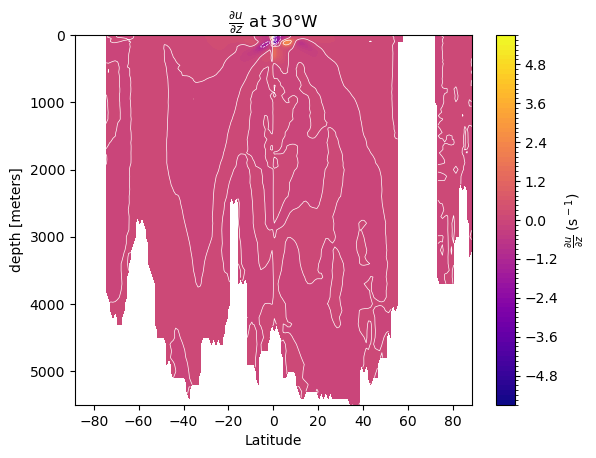

In [24]:
fig,ax=plt.subplots()
x=dudz.plot.contourf(ax=ax,x="lat",y="depth",levels=80,yincrease=False,cmap=plt.colormaps['plasma'],add_colorbar=False) #not usually a plasma user but this is really dramatic
dudz.plot.contour(ax=ax,x="lat",y="depth",levels=10,yincrease=False,colors='white',linewidths=0.5)
ax.set_xlabel('Latitude')
ax.set_ylabel=('Depth (m)')
ax.set_title(r'$\frac{\partial u}{\partial z}$ at 30°W')
cb=fig.colorbar(x,ax=ax)
cb.set_label(label=r'$\frac{\partial u}{\partial z}$ (s$^-$$^1$)')

### todo: select 1000 m as your reference level (or level of no motion) and cumulatively integrate from z = -1000 m to the surface to obtain a profile of zonal velocity $u$

We'll first ignore everything below z = -1000 m and assume $u$ is zero at z = -1000 m. At each latitude, calculate a cumulative vertical  sum of the right hand side, at each level multiplied by $dz$ (the vertical distance separating values), upwards from z = -1000 m ... this approximates a $du$ that when cumulatively summed approximated the total vertical integral.

todo: plot $u$ over this cross-section and across this depth range (spanning all latitudes between z = 0 m and z = -1000 m)

In [25]:
dudz_1000=dudz.sel(depth=slice(0,1000))
depth_1000=dudz_1000.depth
dz_1000=depth_1000.diff("depth")
dz_1000

<xarray.DataArray 'depth' (depth: 46)>
array([ 5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,
        5.,  5.,  5.,  5.,  5.,  5.,  5., 25., 25., 25., 25., 25., 25.,
       25., 25., 25., 25., 25., 25., 25., 25., 25., 25., 50., 50., 50.,
       50., 50., 50., 50., 50., 50., 50.], dtype=float32)
Coordinates:
  * depth    (depth) float32 5.0 10.0 15.0 20.0 25.0 ... 850.0 900.0 950.0 1e+03

In [26]:
#if u at 1000 m is 0, then du/dz at 1000 m is 0 
#we can integrate using the .cumsum function
du_1000=dudz_1000*dz_1000
du_1000=du_1000.sortby('depth',ascending=False)
du_int_1000=du_1000.cumsum('depth')
du_int_1000

<xarray.DataArray (lat: 178, depth: 46)>
dask.array<nancumsum, shape=(178, 46), dtype=float64, chunksize=(45, 25), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float32 -88.5 -87.5 -86.5 -85.5 -84.5 ... 85.5 86.5 87.5 88.5
  * depth    (depth) float32 1e+03 950.0 900.0 850.0 ... 20.0 15.0 10.0 5.0

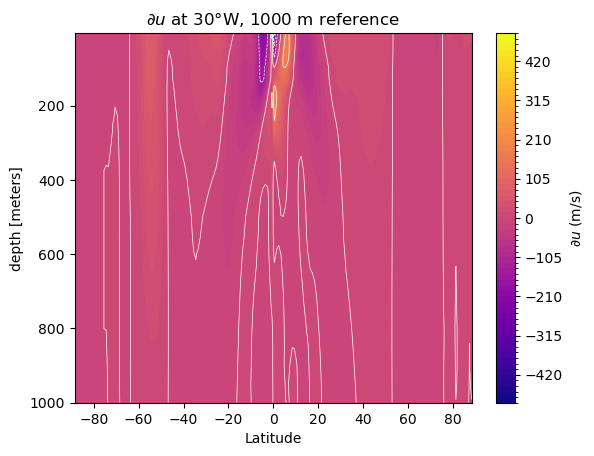

In [27]:
fig,ax=plt.subplots()
x=du_int_1000.plot.contourf(ax=ax,x="lat",y="depth",levels=80,yincrease=False,cmap=plt.colormaps['plasma'],add_colorbar=False)
du_int_1000.plot.contour(ax=ax,x="lat",y="depth",levels=10,yincrease=False,colors='white',linewidths=0.5)
ax.set_xlabel('Latitude')
ax.set_ylabel=('Depth (m)')
ax.set_title(r'${\partial u}$ at 30°W, 1000 m reference')
cb=fig.colorbar(x,ax=ax)
cb.set_label(label=r'${\partial u}$ (m/s)')

### todo: redo the above calculation starting at z = -3000 m and then again at the seafloor

In [28]:
dudz_3000=dudz.sel(depth=slice(0,3000))
depth_3000=dudz_3000.depth
dz_3000=depth_3000.diff("depth")
dz_3000

<xarray.DataArray 'depth' (depth: 76)>
array([  5.,   5.,   5.,   5.,   5.,   5.,   5.,   5.,   5.,   5.,   5.,
         5.,   5.,   5.,   5.,   5.,   5.,   5.,   5.,   5.,  25.,  25.,
        25.,  25.,  25.,  25.,  25.,  25.,  25.,  25.,  25.,  25.,  25.,
        25.,  25.,  25.,  50.,  50.,  50.,  50.,  50.,  50.,  50.,  50.,
        50.,  50.,  50.,  50.,  50.,  50.,  50.,  50.,  50.,  50.,  50.,
        50.,  50.,  50.,  50.,  50.,  50.,  50.,  50.,  50.,  50.,  50.,
       100., 100., 100., 100., 100., 100., 100., 100., 100., 100.],
      dtype=float32)
Coordinates:
  * depth    (depth) float32 5.0 10.0 15.0 20.0 ... 2.8e+03 2.9e+03 3e+03

In [29]:
du_3000=dudz_3000*dz_3000
du_3000=du_3000.sortby('depth',ascending=False)
du_int_3000=du_3000.cumsum('depth')
du_int_3000

<xarray.DataArray (lat: 178, depth: 76)>
dask.array<nancumsum, shape=(178, 76), dtype=float64, chunksize=(45, 26), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float32 -88.5 -87.5 -86.5 -85.5 -84.5 ... 85.5 86.5 87.5 88.5
  * depth    (depth) float32 3e+03 2.9e+03 2.8e+03 2.7e+03 ... 15.0 10.0 5.0

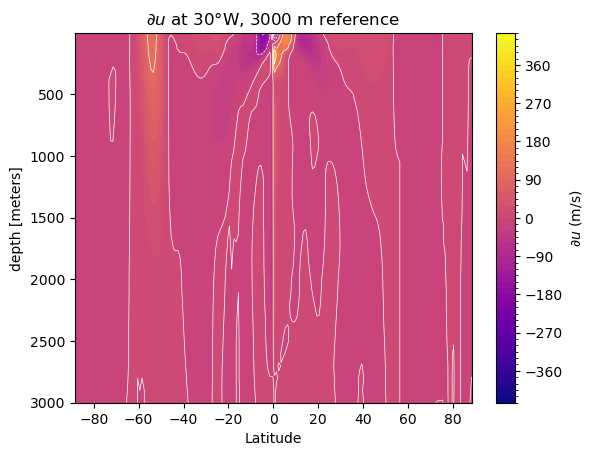

In [30]:
fig,ax=plt.subplots()
x=du_int_3000.plot.contourf(ax=ax,x="lat",y="depth",levels=80,yincrease=False,cmap=plt.colormaps['plasma'],add_colorbar=False)
du_int_3000.plot.contour(ax=ax,x="lat",y="depth",levels=10,yincrease=False,colors='white',linewidths=0.5)
ax.set_xlabel('Latitude')
ax.set_ylabel=('Depth (m)')
ax.set_title(r'${\partial u}$ at 30°W, 3000 m reference')
cb=fig.colorbar(x,ax=ax)
cb.set_label(label=r'${\partial u}$ (m/s)')

### todo: consider how estimates of $u$ over the upper 1000 m change as the refence level deepends. Write a few sentences about these differences, describe the features of $u$ that you observe, and connect them to know currents. 

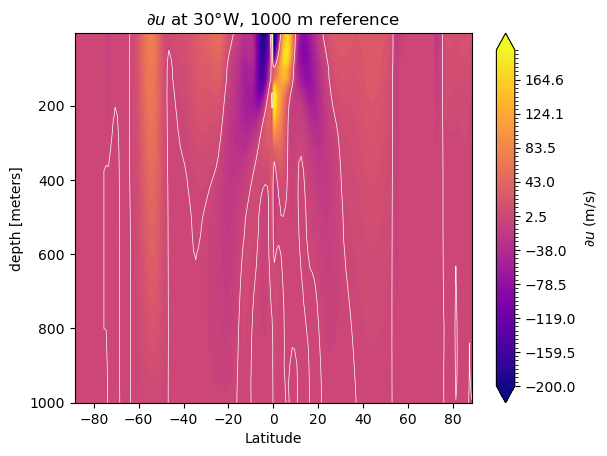

In [31]:
#this is for direct analysis
fig,ax=plt.subplots()
x=du_int_1000.plot.contourf(ax=ax,x="lat",y="depth",levels=80,yincrease=False,cmap=plt.colormaps['plasma'],add_colorbar=False,vmin=-200,vmax=200)
du_int_1000.plot.contour(ax=ax,x="lat",y="depth",levels=[0],yincrease=False,colors='white',linewidths=0.5,vmin=-200,vmax=200)
ax.set_xlabel('Latitude')
ax.set_ylabel=('Depth (m)')
ax.set_title(r'${\partial u}$ at 30°W, 1000 m reference')
cb=fig.colorbar(x,ax=ax)
cb.set_label(label=r'${\partial u}$ (m/s)')

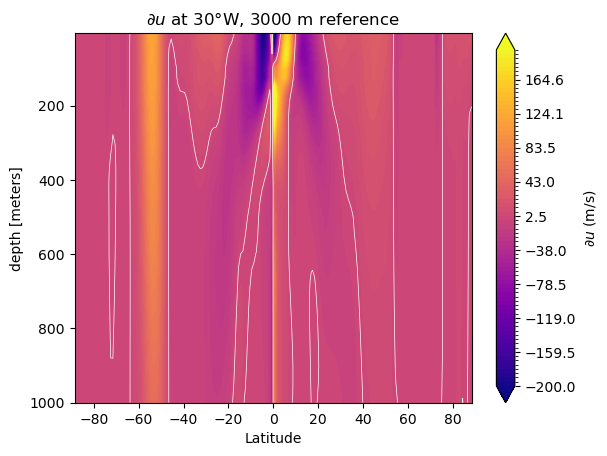

In [32]:
#for direct analysis
fig,ax=plt.subplots()
x=du_int_3000.sel(depth=slice(1000,0)).plot.contourf(ax=ax,x="lat",y="depth",levels=80,yincrease=False,cmap=plt.colormaps['plasma'],add_colorbar=False,vmin=-200,vmax=200)
du_int_3000.sel(depth=slice(1000,0)).plot.contour(ax=ax,x="lat",y="depth",levels=[0],yincrease=False,colors='white',linewidths=0.5,vmin=-200,vmax=200)
ax.set_xlabel('Latitude')
ax.set_ylabel=('Depth (m)')
ax.set_title(r'${\partial u}$ at 30°W, 3000 m reference')
cb=fig.colorbar(x,ax=ax)
cb.set_label(label=r'${\partial u}$ (m/s)')

The positive values mean that wind shear is increasing in the eastward direction, and the negative values mean it is increasing in the westward direction. The location of shifting directions is the same in both tests, but the depth of these features is generally more extensive for the 3000 m reference. This makes sense--the location of shifts should only change in the z direction because the only thing shifting is the depth that du is 0.             

At 30°W, this transect is looking at the Atlantic. There is a very strong eastward shear just north the equator, and a strong eastward shear at -50 to -60 degrees latitude. There is a very strong westward shear just south of the Equator, and a notable westward shear at about 10 to 20 degrees latitude. Other regions are fairly standard, with values close to zero and weak shear. The core of the ACC aligns with the strong eastward shear around -50 to -60 latitudes, and this carries downwards directly. Moving westward is the South Equatorial Current, which completes the loop of the South Atlantic Gyre. The North Equatorial Current is likely where the westward shear occurs around 15 degrees. The moderate eastward shear around 40 to 50 degrees is probably a result of the North Atlantic Current, which isn't as streamlined as the other eastward currents in this transect. Finally, there's a strong eastward shear just north of the equator. This is very strong from the surface to about 300 m, for both plots. This one confused me, but it seems like it's the Equatorial Undercurrent and the North Equatorial Countercurrent. The Equatorial Undercurrent is driven by the fact that water piles up at the Equator. The North Equatorial Countercurrent is more confusing to me, but it seems like it's set up by the ITCZ.